# analysis.organism-range

In this notebook we will study the *organism range*, a property that could be seen as the analogue of organism *host-range* in hosts. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from daforfer import DaforferDB
import powerlaw
import networkx as nx
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()

┌────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                name                │                                                                                  description                                                                                   │
│              varchar               │                                                                                    varchar                                                                                     │
├────────────────────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_bacteriaHits                     │ This table contains all the MOTUS hits obtained, regardless of their status. It contains the libr

## Load data

In [3]:
metadata = db.conn.sql('SELECT * FROM D_sites').df()
bacteria_hits = db.conn.sql('SELECT * FROM D_PABHits').df()
virus_hits = db.conn.sql('SELECT * FROM D_virusHits').df()

# bacteria_hits = pd.read_csv("output/hits.bacteria.csv", sep=";").query("is_pab==True")
bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left').dropna(subset='taxid')
bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)

# virus_hits = pd.read_csv("output/hits.virus.csv", sep=";")
virus_hits = pd.merge(metadata, virus_hits, on='library', how='left').dropna(subset='taxid')
virus_hits['taxid'] = virus_hits['taxid'].astype(int)

## Organism range calculation

In [4]:

host_bacteria_range = bacteria_hits.value_counts(
    ['host_taxon', 'taxid']
    ).reset_index().value_counts(
        ['host_taxon']
    ).reset_index().rename(columns={'count': 'bacteria_range'})

host_bacteria_range

,host_taxon,bacteria_range
0,Conyza bonariensis,43
1,Bromus sp,37
2,Convolvulus arvensis,37
3,Amaranthus sp,17
4,Diplotaxis erucoides,17
...,...,...
70,Lavandula latifolia,1
71,Lithodora fruticosa,1
72,Marrubium vulgare,1
73,Phlomis lychnitis,1


In [5]:
host_virus_range = virus_hits.value_counts(
    ['host_taxon', 'taxid']
    ).reset_index().value_counts(
        ['host_taxon']
    ).reset_index().rename(columns={'count': 'virus_range'})
host_virus_range

,host_taxon,virus_range
0,Diplotaxis erucoides,40
1,Picris echioides,35
2,Rubia peregrina,32
3,Amaranthus sp,31
4,Convolvulus arvensis,31
...,...,...
101,Dittrichia viscosa,1
102,Melilotus sp,1
103,Crataegus monogyna,1
104,Aphyllanthes monspeliensis,1


In [6]:
organism_range = pd.merge(host_bacteria_range, host_virus_range, on='host_taxon', how='outer').fillna(0)
# WE will save this dataframe later
organism_range

,host_taxon,bacteria_range,virus_range
0,Allium sativum,0.0,3.0
1,Amaranthus sp,17.0,31.0
2,Anacyclus clavatus,7.0,11.0
3,Anchusa undulata,5.0,19.0
4,Andryala arenaria,5.0,2.0
...,...,...,...
108,Trifolium tomentosum,1.0,2.0
109,Verbascum sinuatum,8.0,10.0
110,Vicia sp,7.0,20.0
111,Xanthium strumarium,0.0,1.0


Below, we will visualize the organisms range using a histogram.

In [7]:
organism_range_melt = organism_range.melt(id_vars=['host_taxon'], value_vars=['bacteria_range', 'virus_range'])
organism_range_melt['variable'] = organism_range_melt['variable'].apply(lambda x: x.replace("_range", ""))
organism_range_melt = organism_range_melt.rename(columns={'variable':'kingdom', 'value':'range'})
organism_range_melt

,host_taxon,kingdom,range
0,Allium sativum,bacteria,0.0
1,Amaranthus sp,bacteria,17.0
2,Anacyclus clavatus,bacteria,7.0
3,Anchusa undulata,bacteria,5.0
4,Andryala arenaria,bacteria,5.0
...,...,...,...
221,Trifolium tomentosum,virus,2.0
222,Verbascum sinuatum,virus,10.0
223,Vicia sp,virus,20.0
224,Xanthium strumarium,virus,1.0


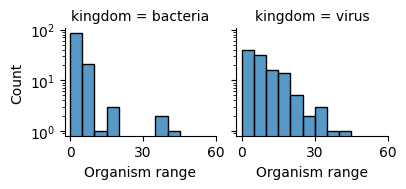

In [8]:

max_range = (organism_range_melt['range'].max() // 5) + 2
bins = np.arange(0, max_range * 5, 5)
g = sns.displot(data=organism_range_melt, x='range', col='kingdom', height=2.0, bins=bins)
g.axes[0, 0].set_yscale('log')
g.axes[0, 0].set_xticks([0, 30, 60])
g.set_xlabels("Organism range")
g.set_ylabels("Count")
g.savefig("figures/displot.organism-range.colbykingdom.svg")

## Regression analysis between bacteria and virus range

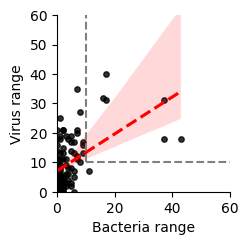

In [9]:
g = sns.lmplot(data=organism_range, x='bacteria_range', y='virus_range', height=2.5,  scatter_kws={'color':'black', 's':15}, line_kws={'color':'red', 'linestyle':'--'})
g.set_xlabels("Bacteria range")
g.set_ylabels("Virus range")
g.ax.set_xlim(0, 60)
g.ax.set_ylim(0, 60)
g.ax.axvline(10, ymin=0.17, ymax=1.0, color='gray', linestyle='--')
g.ax.axhline(10, xmin=0.17, xmax=1.0, color='gray', linestyle='--')
g.savefig("figures/linreg.bact-range.virus-range.svg")

In [10]:
test_1 = stats.linregress(organism_range['bacteria_range'], organism_range['virus_range'])

test_1_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Regression between bacteria and virus range"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":"No correlation between number of libraries and species richness"},
    {"key": "H1", "value":"Correlation between number of libraries and species richness"},
    {"key": "p-value", "value": test_1.pvalue}, # type: ignore
    {"key": "significative", "value": test_1.pvalue < 0.05}, # type: ignore
    {"key": "intercept", "value": test_1.intercept}, # type: ignore
    {"key": "slope", "value": test_1.slope}, # type: ignore
    {"key": "r-value", "value": test_1.rvalue}, # type: ignore
    {"key": "R2", "value": test_1.rvalue ** 2} # type: ignore

])

db.save_dataframe(test_1_results, "T_orgRangeCorr", "Regression between bacteria and virus range")
test_1_results



Saved T_orgRangeCorr to 2025-10-21


,key,value
0,title,Regression between bacteria and virus range
1,test-type,Regression
2,H0,No correlation between number of libraries and...
3,H1,Correlation between number of libraries and sp...
4,p-value,0.0
5,significative,True
6,intercept,7.040654
7,slope,0.628515
8,r-value,0.516628
9,R2,0.266904


## Computing total organism range

In [11]:
organism_range['total'] = organism_range['bacteria_range'] + organism_range['virus_range']
organism_range.sort_values(by='total', ascending=False)

,host_taxon,bacteria_range,virus_range,total
27,Convolvulus arvensis,37.0,31.0,68.0
28,Conyza bonariensis,43.0,18.0,61.0
40,Diplotaxis erucoides,17.0,40.0,57.0
21,Bromus sp,37.0,18.0,55.0
1,Amaranthus sp,17.0,31.0,48.0
...,...,...,...,...
61,Lavandula latifolia,1.0,0.0,1.0
13,Astragalus sesameus,1.0,0.0,1.0
64,Lithodora fruticosa,1.0,0.0,1.0
72,Melilotus sp,0.0,1.0,1.0


## Cooccurrences at host level

Now, let's also include whether these organisms also include a higher number of cooccurrences. We will load first the cooccurrence network

In [12]:
G = nx.read_graphml("output/network.coocurrence.virusbact-bylibrary.trans.graphml")
#nx.draw(G)
G.nodes(data=True)

NodeDataView({'Beet chlorosis virus': {}, 'Duffyella gerundensis': {}, 'Frigoribacterium sp. Leaf164': {}, 'Pseudomonas oryzihabitans': {}, 'Rhodococcoides fascians': {}, 'Beet mild yellowing virus': {}, 'Beet western yellows virus': {}, 'Agrobacterium tumefaciens': {}, 'Arthrobacter sp. Leaf234': {}, 'Pseudomonas sp. Leaf127': {}, 'Sphingomonas sp. Leaf20': {}, 'Cucumber mosaic virus RNA 3': {}, 'Maize dwarf mosaic virus': {}, 'Parietaria mottle virus RNA 3': {}, 'Xanthomonas campestris': {}, 'Pelargonium zonate spot virus RNA 3': {}, 'Pepper mild mottle virus': {}, 'Frigoribacterium sp. Leaf186': {}, 'Pantoea ananatis': {}, 'Sanguibacter sp. Leaf3': {}, 'Rubus chlorotic mottle virus': {}, 'Tobacco mild green mosaic virus': {}, 'Methylobacterium sp. Leaf125': {}, 'Pseudomonas punonensis': {}, 'Rhizobium sp. Leaf311': {}, 'Sphingomonas sp. Leaf208': {}, 'Xylophilus sp. Leaf220': {}, 'Tobacco mosaic virus': {}, 'Curtobacterium flaccumfaciens': {}, 'Rhizobium sp. NFR03': {}, 'Tomato aspe

Now, we need to count the number of cooccurrences in each host. For that, first we need to get whole lists of all the organisms detected in a given host. For that, we will convert all organisms detected in a given host into a list. 

In [13]:

host_bacteria_range_scientific_name = bacteria_hits.value_counts(
    ['host_taxon', 'scientific_name']
    ).reset_index().groupby(
        ['host_taxon'], as_index=False
    )['scientific_name'].apply(list)

host_virus_range_scientific_name = virus_hits.value_counts(
    ['host_taxon', 'scientific_name']
    ).reset_index().groupby(
        ['host_taxon'], as_index=False
    )['scientific_name'].apply(list)

host_organism_range_scientific_name = pd.merge(host_bacteria_range_scientific_name, host_virus_range_scientific_name, on='host_taxon')
host_organism_range_scientific_name

,host_taxon,scientific_name_x,scientific_name_y
0,Amaranthus sp,"[Arthrobacter sp. Leaf234, Rhodococcoides fasc...","[Rubus chlorotic mottle virus, Watermelon mosa..."
1,Anacyclus clavatus,"[Rhodococcoides fascians, Pseudomonas oryzihab...","[Cucumber mosaic virus RNA 3, Pelargonium zona..."
2,Anchusa undulata,"[Chryseobacterium sp. Leaf201, Aureimonas sp. ...","[Rubus chlorotic mottle virus, Pelargonium zon..."
3,Andryala arenaria,"[Ralstonia sp. MD27, Pseudomonas lutea, Methyl...","[Tobacco mild green mosaic virus, Youcai mosai..."
4,Anthriscus caucalis,[Methylobacterium sp. Leaf125],"[Pelargonium zonate spot virus RNA 3, Tomato a..."
...,...,...,...
63,Tragopogon sp,[Duffyella gerundensis],"[Ixeridium yellow mottle virus 1, Beet chloros..."
64,Trifolium tomentosum,[Pseudomonas lutea],"[Barley yellow dwarf virus - PAV, Barley yello..."
65,Verbascum sinuatum,"[Rhodococcoides fascians, Curtobacterium flacc...","[Cucumber mosaic virus RNA 3, Tobacco mosaic v..."
66,Vicia sp,"[Frigoribacterium sp. Leaf186, Duffyella gerun...","[Beet mild yellowing virus, Beet western yello..."


Now, we can make subnetworks out of the original network, and simply count the number of edges.

In [14]:
host_organism_range_scientific_name['network'] = host_organism_range_scientific_name.apply(
    lambda x: G.subgraph(x.scientific_name_x + x.scientific_name_y), axis=1
)
host_organism_range_scientific_name['n_cooccurrences'] = host_organism_range_scientific_name['network'].apply(lambda x: x.number_of_edges())
host_organism_range_scientific_name

,host_taxon,scientific_name_x,scientific_name_y,network,n_cooccurrences
0,Amaranthus sp,"[Arthrobacter sp. Leaf234, Rhodococcoides fasc...","[Rubus chlorotic mottle virus, Watermelon mosa...","(Beet chlorosis virus, Duffyella gerundensis, ...",35
1,Anacyclus clavatus,"[Rhodococcoides fascians, Pseudomonas oryzihab...","[Cucumber mosaic virus RNA 3, Pelargonium zona...","(Duffyella gerundensis, Cucumber mosaic virus ...",9
2,Anchusa undulata,"[Chryseobacterium sp. Leaf201, Aureimonas sp. ...","[Rubus chlorotic mottle virus, Pelargonium zon...","(Agrobacterium tumefaciens, Watermelon mosaic ...",4
3,Andryala arenaria,"[Ralstonia sp. MD27, Pseudomonas lutea, Methyl...","[Tobacco mild green mosaic virus, Youcai mosai...","(Duffyella gerundensis, Tobacco mild green mos...",3
4,Anthriscus caucalis,[Methylobacterium sp. Leaf125],"[Pelargonium zonate spot virus RNA 3, Tomato a...","(Tomato aspermy virus RNA 3, Cucumber mosaic v...",0
...,...,...,...,...,...
63,Tragopogon sp,[Duffyella gerundensis],"[Ixeridium yellow mottle virus 1, Beet chloros...","(Duffyella gerundensis, Tobacco mild green mos...",3
64,Trifolium tomentosum,[Pseudomonas lutea],"[Barley yellow dwarf virus - PAV, Barley yello...",(Pseudomonas lutea),0
65,Verbascum sinuatum,"[Rhodococcoides fascians, Curtobacterium flacc...","[Cucumber mosaic virus RNA 3, Tobacco mosaic v...","(Agrobacterium tumefaciens, Watermelon mosaic ...",3
66,Vicia sp,"[Frigoribacterium sp. Leaf186, Duffyella gerun...","[Beet mild yellowing virus, Beet western yello...","(Beet chlorosis virus, Duffyella gerundensis, ...",23


In [20]:
organism_range = pd.merge(organism_range, host_organism_range_scientific_name[['host_taxon', 'n_cooccurrences']], on='host_taxon', how='outer').fillna(0)
organism_range['all_possible_cooccurrences'] = organism_range['bacteria_range'] * organism_range['virus_range']
pd.merge(organism_range, metadata[['host_taxon', 'habitat']].drop_duplicates().groupby('host_taxon', as_index=False)['habitat'].apply(lambda x: ", ".join(list(x))), on='host_taxon')
db.save_dataframe(
    organism_range, table_name="D_organismRange", 
    description="Hosts bacteria and virus ranges"
)
organism_range

Saved D_organismRange to 2025-10-21


,host_taxon,bacteria_range,virus_range,total,n_cooccurrences_x,all_possible_cooccurrences,n_cooccurrences_y,n_cooccurrences
0,Allium sativum,0.0,3.0,3.0,0.0,0.0,0.0,0.0
1,Amaranthus sp,17.0,31.0,48.0,35.0,527.0,35.0,35.0
2,Anacyclus clavatus,7.0,11.0,18.0,9.0,77.0,9.0,9.0
3,Anchusa undulata,5.0,19.0,24.0,4.0,95.0,4.0,4.0
4,Andryala arenaria,5.0,2.0,7.0,3.0,10.0,3.0,3.0
...,...,...,...,...,...,...,...,...
108,Trifolium tomentosum,1.0,2.0,3.0,0.0,2.0,0.0,0.0
109,Verbascum sinuatum,8.0,10.0,18.0,3.0,80.0,3.0,3.0
110,Vicia sp,7.0,20.0,27.0,23.0,140.0,23.0,23.0
111,Xanthium strumarium,0.0,1.0,1.0,0.0,0.0,0.0,0.0


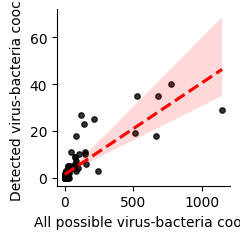

In [21]:
g = sns.lmplot(data=organism_range, x='all_possible_cooccurrences', y='n_cooccurrences', height=2.5,  scatter_kws={'color':'black', 's':15}, line_kws={'color':'red', 'linestyle':'--'})
g.set_xlabels("All possible virus-bacteria cooc.")
g.set_ylabels("Detected virus-bacteria cooc.")

In [22]:
test_2 = stats.linregress(organism_range['all_possible_cooccurrences'], organism_range['n_cooccurrences'])

test_2_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Possible cooccurrences versus detected cooccurrences"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":"No correlation between number of libraries and species richness"},
    {"key": "H1", "value":"Correlation between number of libraries and species richness"},
    {"key": "p-value", "value": test_2.pvalue}, #type: ignore
    {"key": "significative", "value": test_2.pvalue < 0.05}, #type: ignore
    {"key": "intercept", "value": test_2.intercept}, #type: ignore
    {"key": "slope", "value": test_2.slope}, #type: ignore
    {"key": "r-value", "value": test_2.rvalue}, #type: ignore
    {"key": "R2", "value": test_2.rvalue ** 2} #type: ignore

])

db.save_dataframe(
    test_2_results, table_name="T_hostCooc", 
    description="Correlation test between possible cooccurences and detected cooccurences at host level"
)
test_2_results


Saved T_hostCooc to 2025-10-21


,key,value
0,title,Possible cooccurrences versus detected cooccur...
1,test-type,Regression
2,H0,No correlation between number of libraries and...
3,H1,Correlation between number of libraries and sp...
4,p-value,0.0
5,significative,True
6,intercept,1.379648
7,slope,0.03921
8,r-value,0.832222
9,R2,0.692594


In [23]:
# pd.merge(organism_range, metadata[['host_taxon', 'habitat']].drop_duplicates().groupby('host_taxon', as_index=False)['habitat'].apply(lambda x: ", ".join(list(x))), on='host_taxon')

In [24]:
db.conn.close()